# 06 · LSTM & GRU Sequence Models

**Phase 11 (LSTM) + Phase 12 (GRU) of the project plan.**

The tabular models in `04`/`05` relied on hand-engineered lag/rolling/EMA features to give the model access to history. Recurrent networks take the opposite approach: feed a **sliding window of raw (scaled) sensor cycles** directly and let the network learn what temporal patterns matter.

This notebook builds on the `*_scaled_base` tables saved by `03_feature_engineering.ipynb` (scaled sensors, before the tabular lag/rolling features were added) rather than the fully-engineered tabular tables — that engineering was specifically to help non-sequential models see history; it isn't needed here.

The training loop itself lives in `src/torch_models.train_regressor` so both models reuse identical optimization code; this notebook only writes and calls it — you decide when to actually run the training cells.


In [1]:
import sys
sys.path.insert(0, "..")

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src import data_loader as dl
from src import sequence as seq
from src import evaluate as ev
from src.torch_models import SequenceDataset, RecurrentRULRegressor, train_regressor, predict

INTERIM_DIR = "../data/interim"
ARTIFACTS_DIR = "../artifacts"
REPORTS_DIR = "../reports"
MODELS_DIR = "../models"
SUBSET = "FD001"
SEQ_LEN = 30  # cycles per window -- a hyperparameter; try 20/50 and compare

torch.manual_seed(42)

train_base = pd.read_parquet(f"{INTERIM_DIR}/train_{SUBSET}_scaled_base.parquet")
val_base = pd.read_parquet(f"{INTERIM_DIR}/val_{SUBSET}_scaled_base.parquet")
test_base = pd.read_parquet(f"{INTERIM_DIR}/test_{SUBSET}_scaled_base.parquet")
rul_true_test = pd.read_parquet(f"{INTERIM_DIR}/rul_{SUBSET}.parquet")["RUL"]

manifest = joblib.load(f"{ARTIFACTS_DIR}/scalers/feature_manifest_{SUBSET}.joblib")
seq_feature_cols = manifest["feature_sensors"] + dl.OP_SETTING_COLS
print(f"{len(seq_feature_cols)} sequence features:", seq_feature_cols)


18 sequence features: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'op_setting_1', 'op_setting_2', 'op_setting_3']


## Building sliding-window sequences

- Train/validation: **every** window of length `SEQ_LEN` per engine (`build_training_sequences`), so the model sees examples at many different points in each engine's life, not just the end.
- Test: exactly **one** window per engine — the most recent `SEQ_LEN` cycles (`build_last_window_per_engine`) — matching how `RUL_FD001.txt` is defined (ground truth at the last observed test cycle).

Engines shorter than `SEQ_LEN` are left-padded rather than dropped (see `src/sequence.py`), so no short engine silently disappears.


In [2]:
train_seq = seq.build_training_sequences(train_base, seq_feature_cols, SEQ_LEN, target_col="RUL")
val_seq = seq.build_training_sequences(val_base, seq_feature_cols, SEQ_LEN, target_col="RUL")
test_seq = seq.build_last_window_per_engine(test_base, seq_feature_cols, SEQ_LEN)

print("train X:", train_seq["X"].shape, " y:", train_seq["y"].shape)
print("val   X:", val_seq["X"].shape, " y:", val_seq["y"].shape)
print("test  X:", test_seq["X"].shape, "(one window per engine)")

y_true_test = rul_true_test.loc[test_seq["engine_ids"]].to_numpy()


train X: (14241, 30, 18)  y: (14241,)
val   X: (3490, 30, 18)  y: (3490,)
test  X: (100, 30, 18) (one window per engine)


In [3]:
BATCH_SIZE = 64

train_loader = DataLoader(SequenceDataset(train_seq["X"], train_seq["y"]), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SequenceDataset(val_seq["X"], val_seq["y"]), batch_size=BATCH_SIZE, shuffle=False)


## Architecture

Shared by both models (`src/torch_models.RecurrentRULRegressor`): recurrent layer → dropout → `Dense(32)` → `ReLU` → `Dense(1)`. Only the recurrent cell type differs (`'lstm'` vs `'gru'`).


## Phase 11 — LSTM

Run this cell to actually train. `train_regressor` prints train/val loss per epoch and stops early once validation loss stops improving for `patience` epochs, then reloads the best-epoch weights before returning.


In [4]:
n_features = len(seq_feature_cols)

lstm_model = RecurrentRULRegressor(n_features=n_features, hidden_size=64, num_layers=1, dropout=0.2, cell_type="lstm")

# Run to train (not executed here -- you decide when):
lstm_history = train_regressor(lstm_model, train_loader, val_loader, epochs=50, lr=1e-3, patience=8)


epoch   1 | train_loss 72.3249 | val_loss 42.1837 *


epoch   2 | train_loss 31.3557 | val_loss 22.8975 *


epoch   3 | train_loss 26.4392 | val_loss 20.7375 *


epoch   4 | train_loss 25.5999 | val_loss 20.4793 *


epoch   5 | train_loss 24.8692 | val_loss 21.0227


...

epoch  18 | train_loss 20.3784 | val_loss 16.9370


epoch  19 | train_loss 19.8166 | val_loss 16.2723


epoch  20 | train_loss 19.4221 | val_loss 17.4078


epoch  21 | train_loss 19.5080 | val_loss 17.5584


epoch  22 | train_loss 19.2534 | val_loss 16.4071
Early stopping at epoch 22 (no val improvement for 8 epochs).


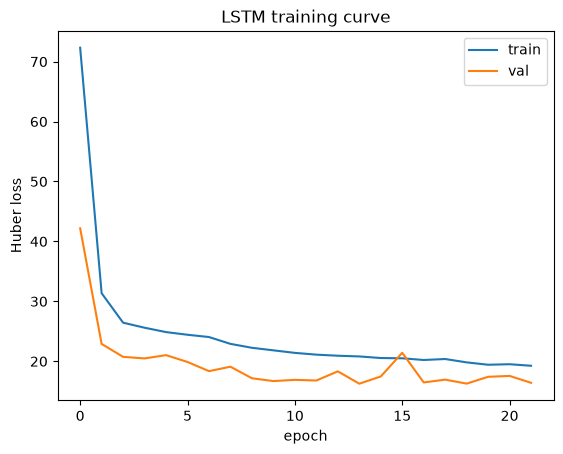

In [5]:
plt.plot(lstm_history["train_loss"], label="train")
plt.plot(lstm_history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("Huber loss")
plt.title("LSTM training curve")
plt.legend()
plt.show()


In [6]:
y_pred_val_lstm = predict(lstm_model, val_seq["X"])
lstm_val_report = {
    **ev.regression_report(val_seq["y"], y_pred_val_lstm),
    "fit_seconds": lstm_history["training_seconds"],
    "n_params": lstm_history["n_params"],
}
lstm_val_report


{'MAE': 16.748851776123047,
 'RMSE': 23.831998916651564,
 'R2': 0.8325890898704529,
 'NASA_score': 93280.75012769122,
 'n': 3490,
 'fit_seconds': 257.8045936000417,
 'n_params': 23617}

## Phase 12 — GRU

Identical setup, swapping the recurrent cell only, so the comparison isolates the LSTM-vs-GRU choice rather than any other confound.


In [7]:
gru_model = RecurrentRULRegressor(n_features=n_features, hidden_size=64, num_layers=1, dropout=0.2, cell_type="gru")

gru_history = train_regressor(gru_model, train_loader, val_loader, epochs=50, lr=1e-3, patience=8)


epoch   1 | train_loss 73.2687 | val_loss 38.9720 *


epoch   2 | train_loss 28.6337 | val_loss 19.0455 *


epoch   3 | train_loss 23.8981 | val_loss 22.1082


epoch   4 | train_loss 22.9822 | val_loss 17.8181 *


epoch   5 | train_loss 22.2871 | val_loss 19.4355


...

epoch  13 | train_loss 19.9801 | val_loss 16.5681


epoch  14 | train_loss 19.6023 | val_loss 16.8865


epoch  15 | train_loss 19.3050 | val_loss 17.0930


epoch  16 | train_loss 19.5117 | val_loss 17.0672


epoch  17 | train_loss 19.1835 | val_loss 17.1485
Early stopping at epoch 17 (no val improvement for 8 epochs).


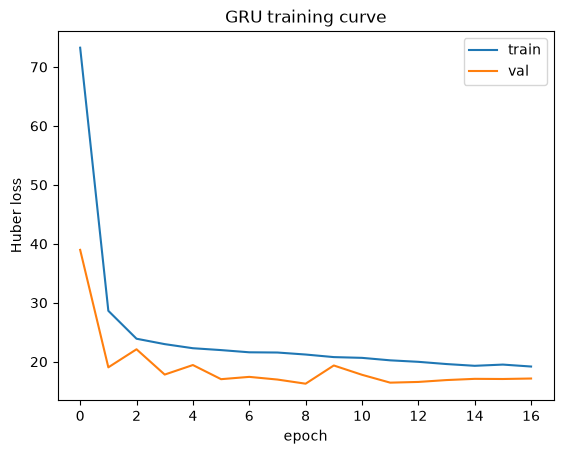

In [8]:
plt.plot(gru_history["train_loss"], label="train")
plt.plot(gru_history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("Huber loss")
plt.title("GRU training curve")
plt.legend()
plt.show()


In [9]:
y_pred_val_gru = predict(gru_model, val_seq["X"])
gru_val_report = {
    **ev.regression_report(val_seq["y"], y_pred_val_gru),
    "fit_seconds": gru_history["training_seconds"],
    "n_params": gru_history["n_params"],
}
gru_val_report


{'MAE': 16.75821876525879,
 'RMSE': 23.70303101291518,
 'R2': 0.8343961238861084,
 'NASA_score': 77956.89301579996,
 'n': 3490,
 'fit_seconds': 258.1734904999612,
 'n_params': 18241}

## LSTM vs. GRU comparison

Same validation windows, same metrics as every earlier notebook, plus parameter count and wall-clock training time — GRU has fewer gates than LSTM (3 vs 4), so it's typically a little faster/smaller for similar accuracy, but this is worth checking empirically on your run rather than assuming it.


In [10]:
seq_comparison = ev.metrics_table({"LSTM": lstm_val_report, "GRU": gru_val_report})
seq_comparison["n_params"] = [lstm_history["n_params"], gru_history["n_params"]]
seq_comparison["fit_seconds"] = [lstm_history["training_seconds"], gru_history["training_seconds"]]
seq_comparison


,MAE,RMSE,R2,NASA_score,n,n_params,fit_seconds
LSTM,16.748852,23.831999,0.832589,93280.750128,3490.0,23617,257.804594
GRU,16.758219,23.703031,0.834396,77956.893016,3490.0,18241,258.173490


In [11]:
tree_leaderboard = pd.read_csv(f"{REPORTS_DIR}/model_leaderboard.csv", index_col=0)
pd.concat([tree_leaderboard[["MAE", "RMSE", "R2", "NASA_score", "n"]], seq_comparison[["MAE", "RMSE", "R2", "NASA_score", "n"]]]).sort_values("MAE")


,MAE,RMSE,R2,NASA_score,n
LSTM,16.748852,23.831999,0.832589,9.328075e+04,3490.0
GRU,16.758219,23.703031,0.834396,7.795689e+04,3490.0
XGBoost,23.062906,31.681936,0.761516,9.760216e+05,4010.0
Random Forest,23.666739,32.988330,0.741442,1.897109e+06,4010.0
LightGBM,23.706452,32.545398,0.748339,1.790216e+06,4010.0
Linear Regression,27.603866,34.314158,0.720242,4.685359e+05,4010.0
Decision Tree,29.383932,41.465260,0.591488,3.457276e+09,4010.0
Constant (mean),54.685121,64.940643,-0.002005,1.694377e+07,4010.0


## Evaluate the better sequence model on the official C-MAPSS test set

This is the same `RUL_FD001.txt` ground truth every earlier notebook has kept fully held out — the real final check, at the single truncation point NASA defined for each test engine.


In [12]:
best_seq_name = seq_comparison["MAE"].idxmin()
best_seq_model = {"LSTM": lstm_model, "GRU": gru_model}[best_seq_name]
print("Best sequence model on validation MAE:", best_seq_name)

y_pred_test = predict(best_seq_model, test_seq["X"])
ev.regression_report(y_true_test, y_pred_test)


Best sequence model on validation MAE: LSTM


{'MAE': 15.238258361816406,
 'RMSE': 21.310526020891867,
 'R2': 0.7370163202285767,
 'NASA_score': 2841.390558137781,
 'n': 100}

In [13]:
ev.evaluate_by_rul_bin(y_true_test, y_pred_test)


,n,MAE,RMSE,NASA_score
bucket,,,,
RUL <= 20,16,2.698438,3.398296,5.206630
20 < RUL <= 50,17,5.246074,6.627000,12.731394
50 < RUL <= 100,34,21.604922,27.787827,2145.063332
RUL > 100,33,19.906070,23.503021,678.389202


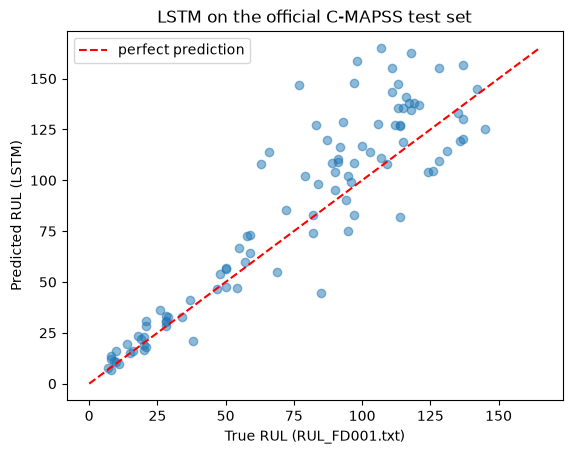

In [14]:
plt.scatter(y_true_test, y_pred_test, alpha=0.5)
lims = [0, max(y_true_test.max(), y_pred_test.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("True RUL (RUL_FD001.txt)")
plt.ylabel(f"Predicted RUL ({best_seq_name})")
plt.title(f"{best_seq_name} on the official C-MAPSS test set")
plt.legend()
plt.show()


## Save both models

Saving both (not just the "winner") since which one generalizes best can be close, and you may want to revisit this after trying different `SEQ_LEN` / hidden sizes.


In [15]:
torch.save(lstm_model.state_dict(), f"{MODELS_DIR}/lstm_{SUBSET}.pt")
torch.save(gru_model.state_dict(), f"{MODELS_DIR}/gru_{SUBSET}.pt")
joblib.dump(
    {"seq_feature_cols": seq_feature_cols, "seq_len": SEQ_LEN, "best_seq_name": best_seq_name},
    f"{MODELS_DIR}/sequence_model_meta_{SUBSET}.joblib",
)
print("saved LSTM + GRU state dicts and metadata")


saved LSTM + GRU state dicts and metadata


## Summary

- Built raw (scaled, non-lagged) sensor sequences per engine — every window for train/validation, the single most-recent window for test — with engine boundaries and short-engine padding both handled by `src/sequence.py`.
- Trained an LSTM and a GRU with an identical architecture/training loop (`src/torch_models.train_regressor`), differing only in recurrent cell type.
- Compared both against every tabular model from `04`/`05` on the same metric set, and evaluated the stronger sequence model against the official, previously-untouched `RUL_FD001.txt` ground truth.
- Saved both trained models + metadata for potential reuse.

**Next:** `07_explainability.ipynb` — SHAP explanations, using the tree model from `05` (fast, exact `TreeExplainer`) rather than the sequence models here (slower/approximate for recurrent nets).
